Continuamos el trabajo para predecir laas Horas Operativas en los próximos 15 días, usando el archivo Datos Agregados.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from skforecast.recursive import ForecasterRecursive
from sklearn.ensemble import RandomForestRegressor

In [70]:
# Cargar el CSV
ruta_csv = "../data/Datos_limpios.csv"
df = pd.read_csv(ruta_csv)

# Mostrar las primeras filas y la info general
primeras_filas = df.head()
info_general = df.info()
resumen_estadistico = df.describe()

primeras_filas, resumen_estadistico


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731742 entries, 0 to 731741
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    731742 non-null  int64  
 1   Tipo_Equipo                  731742 non-null  int64  
 2   Fabricante                   731742 non-null  int64  
 3   Modelo                       731742 non-null  int64  
 4   Potencia_kW                  731742 non-null  float64
 5   Horas_Recomendadas_Revision  731742 non-null  float64
 6   ID_Orden                     731742 non-null  float64
 7   Fecha                        731742 non-null  object 
 8   Tipo_Mantenimiento           731742 non-null  int64  
 9   Costo_Mantenimiento          731742 non-null  float64
 10  Duracion_Horas               731742 non-null  float64
 11  Ubicacion                    731742 non-null  int64  
 12  ID_Registro                  731742 non-null  int64  
 13 

(   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
 0          1            0           2       6        173.0   
 1          1            0           2       6        173.0   
 2          1            0           2       6        173.0   
 3          1            0           2       6        173.0   
 4          1            0           2       6        173.0   
 
    Horas_Recomendadas_Revision  ID_Orden       Fecha  Tipo_Mantenimiento  \
 0                        913.0       1.0  2021-01-09                   0   
 1                        913.0       1.0  2021-01-10                   0   
 2                        913.0       1.0  2021-01-11                   0   
 3                        913.0       1.0  2021-01-12                   0   
 4                        913.0       1.0  2021-01-13                   0   
 
    Costo_Mantenimiento  ...  Ubicacion  ID_Registro  Temperatura_C  \
 0               3992.0  ...          2            9      69.298440   
 1            

In [73]:
df_filtrado = df[df['ID_Equipo']==1]
df_filtrado

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,ID_Orden,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,...,Ubicacion,ID_Registro,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Dia,Quincena,Mes,Año,horas_hasta_correctivo
0,1,0,2,6,173.0,913.0,1.0,2021-01-09,0,3992.0,...,2,9,69.298440,6.510735,0,9,1,1,2021,913.0
1,1,0,2,6,173.0,913.0,1.0,2021-01-10,0,3992.0,...,2,10,50.938025,0.338625,20,10,1,1,2021,893.0
2,1,0,2,6,173.0,913.0,1.0,2021-01-11,0,3992.0,...,2,11,24.083260,3.659173,41,11,1,1,2021,872.0
3,1,0,2,6,173.0,913.0,1.0,2021-01-12,0,3992.0,...,2,12,49.907242,7.917208,62,12,1,1,2021,851.0
4,1,0,2,6,173.0,913.0,1.0,2021-01-13,0,3992.0,...,2,13,69.407683,2.912719,63,13,1,1,2021,850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,1,0,2,6,173.0,913.0,106.0,2024-12-27,1,769.0,...,2,1457,38.587761,2.748949,808,27,2,12,2024,105.0
1451,1,0,2,6,173.0,913.0,106.0,2024-12-28,1,769.0,...,2,1458,90.397197,5.382844,812,28,2,12,2024,101.0
1452,1,0,2,6,173.0,913.0,106.0,2024-12-29,1,769.0,...,2,1459,21.104524,5.686564,824,29,2,12,2024,89.0
1453,1,0,2,6,173.0,913.0,106.0,2024-12-30,1,769.0,...,2,1460,30.559628,7.948501,828,30,2,12,2024,85.0


In [74]:
df_filtrado_ok = df_filtrado.copy()

Comenzamos con el trabajo de búsqueda de modelo de Serie Temporal para prediccion de Horas_Operativas en los próximos 15 días

In [75]:
df_filtrado_ok['Fecha'] = pd.to_datetime(df_filtrado_ok['Fecha'], format= '%Y-%m-%d')
print(df_filtrado_ok.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1455 entries, 0 to 1454
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID_Equipo                    1455 non-null   int64         
 1   Tipo_Equipo                  1455 non-null   int64         
 2   Fabricante                   1455 non-null   int64         
 3   Modelo                       1455 non-null   int64         
 4   Potencia_kW                  1455 non-null   float64       
 5   Horas_Recomendadas_Revision  1455 non-null   float64       
 6   ID_Orden                     1455 non-null   float64       
 7   Fecha                        1455 non-null   datetime64[ns]
 8   Tipo_Mantenimiento           1455 non-null   int64         
 9   Costo_Mantenimiento          1455 non-null   float64       
 10  Duracion_Horas               1455 non-null   float64       
 11  Ubicacion                    1455 non-null   int

In [76]:
df_filtrado_ok = df_filtrado_ok.sort_values(by='Fecha')
print(df_filtrado_ok.head(5))

   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
0          1            0           2       6        173.0   
1          1            0           2       6        173.0   
2          1            0           2       6        173.0   
3          1            0           2       6        173.0   
4          1            0           2       6        173.0   

   Horas_Recomendadas_Revision  ID_Orden      Fecha  Tipo_Mantenimiento  \
0                        913.0       1.0 2021-01-09                   0   
1                        913.0       1.0 2021-01-10                   0   
2                        913.0       1.0 2021-01-11                   0   
3                        913.0       1.0 2021-01-12                   0   
4                        913.0       1.0 2021-01-13                   0   

   Costo_Mantenimiento  ...  Ubicacion  ID_Registro  Temperatura_C  \
0               3992.0  ...          2            9      69.298440   
1               3992.0  ...         

In [98]:
#Fecha como índice
df_fil_index_data= df_filtrado_ok.set_index('Fecha', inplace= False)

#Eliminar índices duplicados y establecer frecuencia
df_filtrado_limpio= df_fil_index_data[~df_fil_index_data.index.duplicated(keep='first')]
df_filtrado_frec = df_filtrado_limpio.asfreq('MS', fill_value=0)
print(df_filtrado_frec.index)


DatetimeIndex(['2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01',
               '2021-06-01', '2021-07-01', '2021-08-01', '2021-09-01',
               '2021-10-01', '2021-11-01', '2021-12-01', '2022-01-01',
               '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01',
               '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01',
               '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01',
               '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01',
               '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01',
               '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01',
               '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01',
               '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='Fecha', freq='MS')


In [99]:
# Verificar que un índice temporal está completo
fecha_inicio = df_filtrado_frec.index.min()
fecha_fin = df_filtrado_frec.index.max()
date_range_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq=df_filtrado_frec.index.freq)
print(f"Índice completo: {(df_filtrado_frec.index == date_range_completo).all()}")

Índice completo: True


Fechas train : 2021-02-01 00:00:00 --- 2023-09-01 00:00:00  (n=32)
Fechas test  : 2023-10-01 00:00:00 --- 2024-12-01 00:00:00  (n=15)


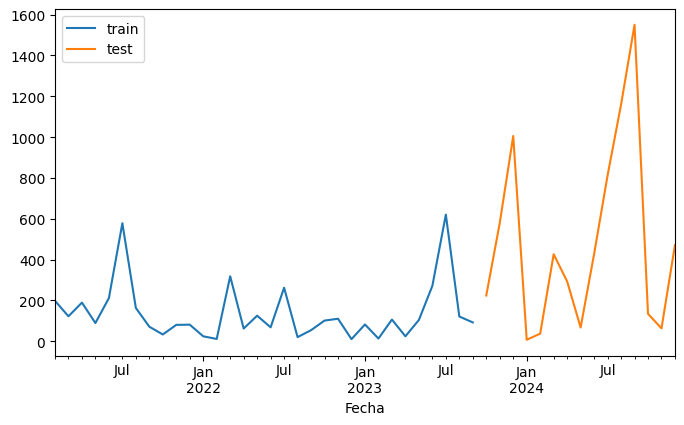

In [103]:
steps = 15
y_train = df_filtrado_frec[:-steps]
y_test  = df_filtrado_frec[-steps:]
print(f"Fechas train : {y_train.index.min()} --- {y_train.index.max()}  (n={len(y_train)})")
print(f"Fechas test  : {y_test.index.min()} --- {y_test.index.max()}  (n={len(y_test)})")
 
fig, ax = plt.subplots(figsize=(8, 4.5))
y_train['Horas_Operativas'].plot(ax=ax, label='train')
y_test['Horas_Operativas'].plot(ax=ax, label='test')
ax.legend();
 

In [104]:
# Crear y entrenar forecaster

forecaster = ForecasterRecursive(
    regressor=RandomForestRegressor(random_state=123),
    lags=10
)

target_series = y_train['Horas_Operativas']      # <- pandas Series 1-D
forecaster.fit(y=target_series)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10] 
Window features: None 
Window size: 10 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2021-02-01 00:00:00'), Timestamp('2023-09-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-04-30 12:37:29 
Last fit date: 2025-04-30 12:37:29 
Skforecast version: 0.15.1 
Python version: 3.10.14 
Forecaster id: None

In [105]:
# Predicciones
steps = 15
predicciones = forecaster.predict(steps=steps)
predicciones.head(20)

2023-10-01    107.31
2023-11-01    145.87
2023-12-01     64.92
2024-01-01     93.83
2024-02-01     45.84
2024-03-01    176.90
2024-04-01     62.77
2024-05-01     76.73
2024-06-01     59.51
2024-07-01     68.47
2024-08-01     60.92
2024-09-01     73.06
2024-10-01     49.49
2024-11-01    108.49
2024-12-01     47.52
Freq: MS, Name: pred, dtype: float64

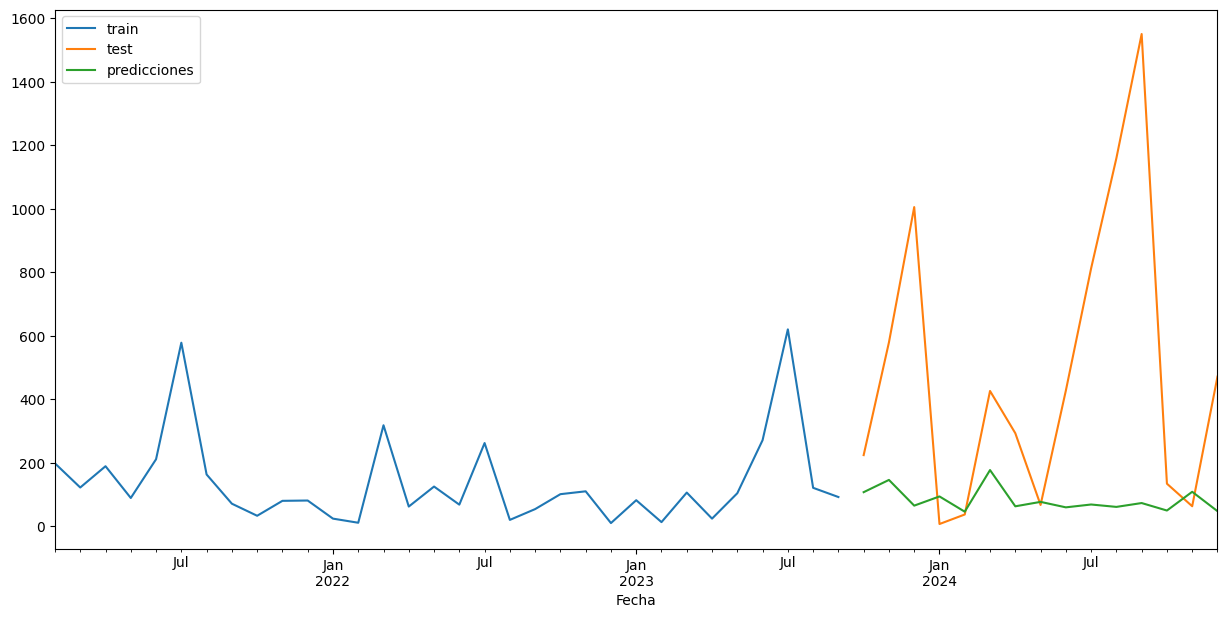

In [106]:
# Gráfico de predicciones vs valores reales

fig, ax = plt.subplots(figsize=(15, 7))
y_train['Horas_Operativas'].plot(ax=ax, label='train')
y_test['Horas_Operativas'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend()